# Controller scenarios — driven by the **Week-4 estimator**

A sibling of `controller_scenarios.ipynb`: the *same* Week-3 control stack on the real
`GG4.Brain`, but the controller's internal model now comes from the **Week-4 offline
estimator** — a zero-offset LGSSM identified on a designed **25,000-step multi-probe
excitation schedule** (`week4/excitation.py` + `week4/identify.py`) — instead of the
Week-3 EM fit from a short uniform probe.

Pick a **controller** and an **estimator** in the config cell, then run the scenarios.
Every scenario drives the same Brain with the same physically-anchored targets, so
swapping the controller or the estimator is a fair, one-line comparison.

**Scenarios**
1. **Track** a sinusoid 2. **Hold a feasible target** 3. **Hold an infeasible target**
(watch it saturate, not blow up) 4. **Adapt to a moving target**

**Estimators**
- `"true"`  — quarantined ground-truth yardstick
- `"em"`    — Week-3 N4SID -> affine EM from one short Uniform[0,1] probe
- `"week4"` — Week-4 zero-offset LGSSM on the rich 25k schedule

> **The bridge.** The Week-4 model is *zero-offset* (`y - bias = C x`). The Week-3 control
> stack consumes an *affine* model `x+ = A x + B u + a`, `y = C x + c`. A zero-offset model
> is exactly the affine model with **`a = 0`, `c = bias`** — so it plugs straight into the
> observer, every controller, and the reachability math with no downstream changes.

> **Kernel:** run with the project venv (`venv/`), which has `GG4` + `torch`. The setup cell
> adds the venv `site-packages` to `sys.path` as a fallback.

## 1 - Config — the only cell you normally edit

In [1]:
# ============================ CONTROL PANEL ============================
CONTROLLER = "MPC"      # OpenLoop | ProportionalFeedback | PI | LQG | LQGI |
                        # PolePlacement | MPC | OffsetFreeMPC
ESTIMATOR  = "week4"    # "true"  = ground-truth yardstick
                        # "em"    = Week-3 N4SID -> affine EM on a short Uniform[0,1] probe
                        # "week4" = Week-4 zero-offset LGSSM on the 25k multi-probe schedule
READOUT    = "pca"      # "pca" = 2-D population readout | "dominant" = 1-D sustainable direction

SEED   = 0              # Brain seed (ground-truth files exist for 0..4)
T_RUN  = 300            # closed-loop steps per scenario
T_CAL  = 1000           # probe length for the Week-3 EM fit (only used when ESTIMATOR == "em")

# Week-4 excitation schedule sizing (drives the offline ID; totals exactly 25,000 steps:
# rest 3000 + prbs 2x4000 + chirp 2x4000 + msine 3000 + lpn 3000).
W4_TREST, W4_TPRBS, W4_TCHIRP, W4_TMSINE, W4_TLPN = 3000, 4000, 4000, 3000, 3000
W4_EM_ITERS = 60        # EM iterations for the Week-4 fit (notebook-speed cap)
# ======================================================================

## 2 - Setup — imports & the Brain factory

In [2]:
import sys, importlib.util
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- locate week3/ and make its packages importable ------------------
ROOT = Path.cwd()
if not (ROOT / "control").exists():          # be forgiving about cwd
    for p in [ROOT] + list(ROOT.parents):
        if (p / "control").exists() and p.name == "week3":
            ROOT = p; break
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT.parent / "week 1"))
# --- fallback: pull GG4 from the project venv if not already importable
if importlib.util.find_spec("GG4") is None:
    for sp in [ROOT.parent / "venv" / "Lib" / "site-packages",
               ROOT.parent / "venv" / "lib" / "site-packages"]:
        if sp.exists():
            sys.path.insert(0, str(sp)); break

from GG4 import Brain
from control.plant import BrainPlant
from control.observer import SteadyStateKalman
from control.controllers import (
    OpenLoop, ProportionalFeedback, PI, LQG, LQGI, PolePlacement, MPC, OffsetFreeMPC,
)
from control.closed_loop import run_closed_loop
from control.readouts import build_readout, auto_proportional_gain, auto_integral_gain
from control.reachability import steady_state_gain, zonotope_vertices
from estimator.identify import EstimatorNew
from analysis.ground_truth import GroundTruthModel
from viz.style import CONTROLLER_COLORS, style_axis

# --- Week-4 estimator modules (offline multi-probe system ID) --------
WEEK4 = ROOT.parent / "week4"
if WEEK4.exists():
    sys.path.insert(0, str(WEEK4))
import excitation as w4exc      # week4 excitation library / build_schedule
import identify as w4id         # week4 identify.fit / FitResult (zero-offset LGSSM)

def brain_plant(seed):
    '''A fresh black-box Brain wrapped in the common plant surface.'''
    return BrainPlant(Brain(random_seed=int(seed)))

print(f"ROOT  = {ROOT}")
print(f"WEEK4 = {WEEK4}")
print("setup OK")

ROOT  = c:\Github\GG4\week3
WEEK4 = c:\Github\GG4\week4
setup OK


## 3 - The Week-4 excitation schedule

This is the **offline drive** the Week-4 estimator is identified on — one continuous
trajectory of designed probes (`rest | prbs-0 | prbs-1 | chirp-0 | chirp-1 | msine | lpn`),
totalling 25,000 steps. The per-channel `prbs`/`chirp` segments hold the other input at 0 to
separate the `B` columns; `msine`/`lpn` drive both channels decorrelated. The plot below is
`u(t)` over the whole schedule, with each segment marked.

schedule: T = 25000 steps over 7 segments; clipping fraction = 6.00e-05  (must be ~0)


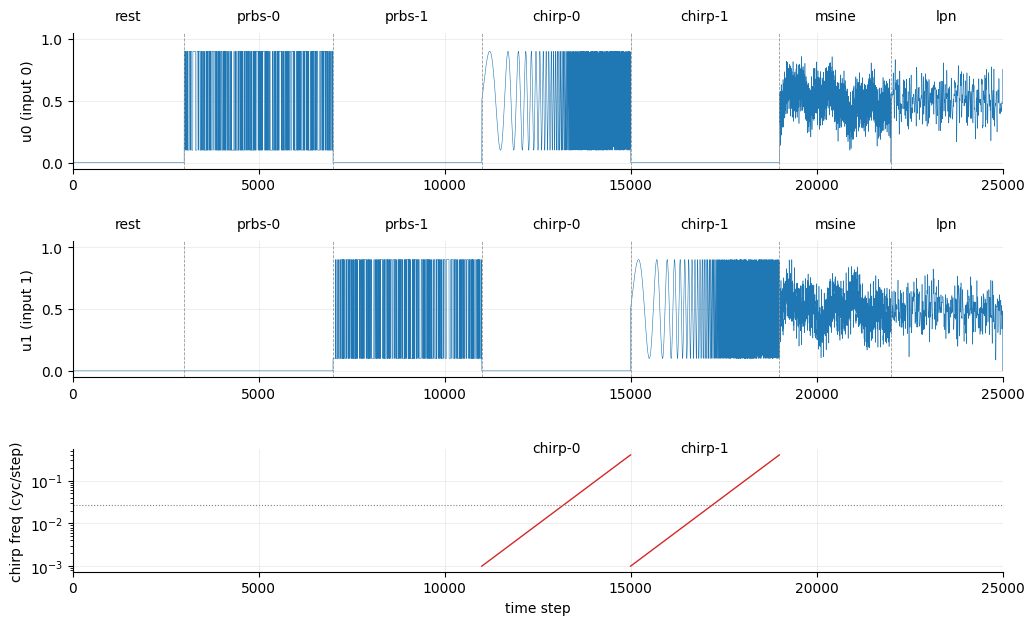

In [19]:
# Build the Week-4 excitation schedule (the offline ID drive) and plot it.
sch = w4exc.build_schedule(seed=SEED, t_rest=W4_TREST, t_prbs=W4_TPRBS,
                           t_chirp=W4_TCHIRP, t_msine=W4_TMSINE, t_lpn=W4_TLPN)
print(f"schedule: T = {sch.T} steps over {len(sch.segments)} segments; "
      f"clipping fraction = {sch.clip_fraction():.2e}  (must be ~0)")

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 0.9], hspace=0.55)
ax0, ax1, axf = (fig.add_subplot(gs[i]) for i in range(3))

for ax, ch, lab in ((ax0, 0, "u0 (input 0)"), (ax1, 1, "u1 (input 1)")):
    ax.plot(sch.U[:, ch], lw=0.4, color="C0")
    ax.set_ylabel(lab); ax.set_ylim(-0.05, 1.05); ax.set_xlim(0, sch.T)
    for name, s, e in sch.segments:
        ax.axvline(s, color="0.6", lw=0.6, ls="--")
        ax.text(0.5 * (s + e), 1.07, name, ha="center", va="bottom",
                fontsize=10, transform=ax.get_xaxis_transform())
    style_axis(ax)

# chirp instantaneous frequency, placed at each chirp segment's global time
axf.set_ylabel("chirp freq (cyc/step)"); axf.set_xlim(0, sch.T)
for name, s, e in sch.segments:
    if name in sch.chirp_freq:
        axf.semilogy(np.arange(s, e), sch.chirp_freq[name], color="C3", lw=1.0)
        axf.text(0.5 * (s + e), sch.chirp_freq[name].max(), name,
                 ha="center", va="bottom", fontsize=10)
axf.axhline(1.0 / 36.5, color="0.5", ls=":", lw=0.8)
axf.set_xlabel("time step")
style_axis(axf)
plt.show()

## 4 - Build the model(s)

We always load the **ground-truth** model (it anchors the targets and is the `"true"`
option). A short Uniform[0,1] probe builds the model-free PCA readout and feeds the Week-3
`"em"` fit. The `"week4"` model drives this SEED's Brain over the 25k schedule above,
de-biases, then runs N4SID -> EM (zero-offset) and returns it in the affine form `a=0,
c=bias`.

`build_model(which)` returns the `(A, B, C, Q, R, a, c)` dict the controller and observer
consume — nothing else downstream changes.

> The `"week4"` branch drives the Brain 25k steps and runs EM, so it takes ~1-2 min the
> first time; the result is cached for re-runs.

In [4]:
# Ground truth (quarantined yardstick) — anchors targets, and is the "true" model.
gt = GroundTruthModel.load(ROOT / "results" / "ground_truth" / f"seed_{SEED}.npz")
TRUE = dict(A=gt.A, B=gt.B, C=gt.C, Q=gt.Q, R=gt.R, a=gt.a, c=gt.c)
N_ORDER = int(gt.A.shape[0])

# Short Uniform[0,1] probe — builds the (model-free) PCA readout and feeds the Week-3 EM fit.
_rng = np.random.default_rng(42 + SEED)
U_cal = _rng.uniform(0.0, 1.0, size=(T_CAL, int(gt.B.shape[1])))
_pl = brain_plant(SEED)
p_obs = len(_pl.measure())
Y_cal = np.empty((T_CAL, p_obs))
_pl = brain_plant(SEED)
Y_cal[0] = _pl.measure(); _pl.next_state(U_cal[0])
for t in range(1, T_CAL):
    Y_cal[t] = _pl.measure(); _pl.next_state(U_cal[t])

_MODEL_CACHE = {}

def _fit_week4():
    '''Run the Week-4 offline ID on this SEED's Brain over the 25k schedule.

    Drives the Brain over sch.U (standard timing), de-biases by the resting-segment mean,
    then N4SID -> EM (zero-offset). Returns the model in the Week-3 AFFINE form with a = 0
    and c = bias  (because  y - bias = C x  <=>  y = C x + c  with c = bias).
    '''
    pl = brain_plant(SEED)
    T = sch.T
    Yraw = np.empty((T, p_obs))
    Yraw[0] = pl.measure(); pl.next_state(sch.U[0])
    for t in range(1, T):
        Yraw[t] = pl.measure(); pl.next_state(sch.U[t])
    rs, re = sch.segments[0][1], sch.segments[0][2]      # the 'rest' segment
    bias = Yraw[rs:re].mean(axis=0)
    Yd = Yraw - bias
    fr = w4id.fit(Yd, sch.U, n=N_ORDER, max_iter=W4_EM_ITERS)
    print(f"  [week4] EM iters {fr.iters}, rho(A_id) = {fr.rho:.4f}, "
          f"|bias|max = {np.abs(bias).max():.3f}")
    return dict(A=fr.A, B=fr.B, C=fr.C, Q=fr.Q, R=fr.R,
                a=np.zeros(fr.A.shape[0]), c=bias)

def build_model(which):
    '''which in {"true","em","week4"} -> dict(A,B,C,Q,R,a,c).'''
    if which == "true":
        return TRUE
    if which not in _MODEL_CACHE:
        if which == "em":
            est = EstimatorNew().fit(Y_cal, U_cal, n=N_ORDER, init="n4sid",
                                     max_iter=80, tol=1e-5)
            _MODEL_CACHE["em"] = dict(A=est.A, B=est.B, C=est.C, Q=est.Q,
                                      R=est.R, a=est.a, c=est.c)
        elif which == "week4":
            _MODEL_CACHE["week4"] = _fit_week4()
        else:
            raise ValueError(f"unknown estimator {which!r}")
    return _MODEL_CACHE[which]

MODEL = build_model(ESTIMATOR)
rho = float(np.max(np.abs(np.linalg.eigvals(MODEL["A"]))))
print(f"controlling with the {ESTIMATOR!r} model   (rho(A) = {rho:.3f}, n = {MODEL['A'].shape[0]})")
if ESTIMATOR == "week4":
    print("note: the Week-4 model is zero-offset; used here as the affine model a=0, c=bias.")

  [week4] EM iters 54, rho(A_id) = 0.9405, |bias|max = 0.292
controlling with the 'week4' model   (rho(A) = 0.941, n = 6)
note: the Week-4 model is zero-offset; used here as the affine model a=0, c=bias.


## 4b - Validate the Week-4 model with a steady-state step (ground-truth-free)

A direct, **empirical** sanity check of the identified Week-4 model that uses **no ground
truth** — only the Brain's own response and the `build_model("week4")` model. We drive a
fresh `brain_plant(SEED)` with clean piecewise-constant steps (rest → hold `u=[1,0]` → rest
→ hold `u=[0,1]`, all amplitudes in `[0,1]`), read the **DC gain** and **slowest timescale**
straight off the plateaus, and compare them against the model's `G = C (I-A)^{-1} B` and its
slowest eigenvalue of `A`. Driving both channels at the same amplitude (1.0) makes the two
gain columns directly comparable — input 1's steady-state effect should be far weaker, and a
good model reproduces that asymmetry.

In [20]:
# --- Steady-state STEP experiment on the real Brain (ground-truth-free) -------
# Drive a fresh Brain with piecewise-constant steps, read off the empirical DC
# gain & slowest timescale, and compare against the Week-4 identified model ONLY.

# Use the Week-4 model dict (reuse MODEL if it is already the week4 one).
m4 = MODEL if ESTIMATOR == "week4" else build_model("week4")
A4, B4, C4 = m4["A"], m4["B"], m4["C"]
c4   = np.asarray(m4["c"], float)        # bias == resting level for a zero-offset model
m_in = B4.shape[1]                       # number of input channels (2)
AMP  = 1.0                               # both channels driven at the same amplitude

# Step schedule (all amplitudes in [0, 1]) -------------------------------------
T_REST0, T_HOLD0, T_REST1, T_HOLD1 = 200, 400, 200, 400
b_rest0 = (0, T_REST0)
b_hold0 = (b_rest0[1], b_rest0[1] + T_HOLD0)             # u = [1, 0]
b_rest1 = (b_hold0[1], b_hold0[1] + T_REST1)
b_hold1 = (b_rest1[1], b_rest1[1] + T_HOLD1)             # u = [0, 1]
T_STEP  = b_hold1[1]

U_step = np.zeros((T_STEP, m_in))
U_step[b_hold0[0]:b_hold0[1], 0] = AMP
U_step[b_hold1[0]:b_hold1[1], 1] = AMP

# Drive a fresh Brain, strict measure-then-step timing -------------------------
pl = brain_plant(SEED)
p_obs_step = len(pl.measure())
pl = brain_plant(SEED)
Y_step = np.empty((T_STEP, p_obs_step))
Y_step[0] = pl.measure(); pl.next_state(U_step[0])
for t in range(1, T_STEP):
    Y_step[t] = pl.measure(); pl.next_state(U_step[t])

# Levels: average over the settled tail of each block so noise cancels ---------
N_REST_AVG, N_HOLD_AVG = 150, 200
resting  = Y_step[b_rest0[1] - N_REST_AVG : b_rest0[1]].mean(axis=0)   # last 150 of rest 0
plateau0 = Y_step[b_hold0[1] - N_HOLD_AVG : b_hold0[1]].mean(axis=0)   # last 200 of hold 0
plateau1 = Y_step[b_hold1[1] - N_HOLD_AVG : b_hold1[1]].mean(axis=0)   # last 200 of hold 1

# Empirical vs model DC gain (16 x 2) ------------------------------------------
G_emp = np.column_stack([(plateau0 - resting) / AMP, (plateau1 - resting) / AMP])
G_mod = C4 @ np.linalg.solve(np.eye(A4.shape[0]) - A4, B4)            # C (I-A)^-1 B, a=0

rel_err   = [np.linalg.norm(G_emp[:, j] - G_mod[:, j]) / np.linalg.norm(G_mod[:, j])
             for j in range(m_in)]
ratio_emp = np.linalg.norm(G_emp[:, 0]) / np.linalg.norm(G_emp[:, 1])
ratio_mod = np.linalg.norm(G_mod[:, 0]) / np.linalg.norm(G_mod[:, 1])

# Slowest timescale from the input-0 step --------------------------------------
ch  = int(np.argmax(np.abs(G_emp[:, 0])))               # output channel that moves most
seg = Y_step[b_hold0[0]:b_hold0[1], ch]
kk  = 5
seg_s = np.convolve(seg, np.ones(kk) / kk, mode="same")  # light smoothing for the crossing
level = (seg_s - resting[ch]) / (plateau0[ch] - resting[ch])
cross = int(np.argmax(level >= 0.6321))                  # first index reaching 63% of final
tau_emp = float(cross) if cross > 0 else np.nan
lam_emp = np.exp(-1.0 / tau_emp)

lam_mod = float(np.max(np.abs(np.linalg.eigvals(A4))))   # slowest mode of the model
tau_mod = -1.0 / np.log(lam_mod)

# Sanity: measured resting level vs the saved bias c ---------------------------
# The zero-offset model has c == resting level, but that level sits near zero
# (|c|max ~ 0.3). We therefore judge closeness against the SIGNAL scale (the
# input-0 response), never relative to c itself (a tiny, noisy denominator).
d_rest         = resting - c4
bias_absmax    = float(np.max(np.abs(d_rest)))
frac_scale     = bias_absmax / np.linalg.norm(G_emp[:, 0])    # vs the input-0 response scale
rest_matches_c = bool(frac_scale < 0.05)

# Report -----------------------------------------------------------------------
print("STEADY-STATE STEP - empirical vs Week-4 model (ground-truth-free)\n")
print(f"channels = {p_obs_step}, inputs = {m_in}, steps = {T_STEP}, drive amp = {AMP}")
print(f"most-responsive output channel for input 0 = {ch}\n")

print("DC gain agreement  ||G_emp[:,j] - G_mod[:,j]|| / ||G_mod[:,j]||:")
for j in range(m_in):
    print(f"  input {j}:  rel.err = {rel_err[j]*100:5.1f}%"
          f"    ||G_emp[:,{j}]|| = {np.linalg.norm(G_emp[:, j]):7.3f}"
          f"    ||G_mod[:,{j}]|| = {np.linalg.norm(G_mod[:, j]):7.3f}")

print(f"\ninput asymmetry  ||col 0|| / ||col 1||:"
      f"   empirical = {ratio_emp:5.1f}    model = {ratio_mod:5.1f}")

print("\nslowest timescale:")
print(f"  empirical   tau ~ {tau_emp:5.1f} steps   (lambda      = {lam_emp:.4f})")
print(f"  model       tau ~ {tau_mod:5.1f} steps   (|lambda|max = {lam_mod:.4f})")

print(f"\nsanity - resting vs saved bias c:  max|delta| = {bias_absmax:.3f}"
      f"   (= {frac_scale*100:.1f}% of the input-0 response scale;  |c|max = {np.abs(c4).max():.3f})")
print(f"         resting matches stored bias c: {rest_matches_c}"
      f"   (rest sits near zero, so a sub-1%-of-scale offset is well within tolerance)")

# Acceptance checks (computed verdicts) ----------------------------------------
chk1 = rel_err[0] <= 0.20
chk2 = (ratio_emp > 3.0) and (ratio_mod > 3.0) and \
       (np.linalg.norm(G_emp[:, 1]) < np.linalg.norm(G_emp[:, 0]))
chk3 = (not np.isnan(tau_emp)) and (0.5 <= tau_emp / tau_mod <= 2.0)
print("\nACCEPTANCE CHECKS")
print(f"  [{'PASS' if chk1 else 'FAIL'}]  input-0 DC gain agrees within ~20%  "
      f"(rel.err = {rel_err[0]*100:.1f}%)")
print(f"  [{'PASS' if chk2 else 'FAIL'}]  input-1 far weaker + large col-norm ratio  "
      f"(emp {ratio_emp:.1f}, mod {ratio_mod:.1f})")
print(f"  [{'PASS' if chk3 else 'FAIL'}]  slowest tau in same ballpark  "
      f"(emp {tau_emp:.1f} vs mod {tau_mod:.1f} steps)")

STEADY-STATE STEP - empirical vs Week-4 model (ground-truth-free)

channels = 16, inputs = 2, steps = 1200, drive amp = 1.0
most-responsive output channel for input 0 = 6

DC gain agreement  ||G_emp[:,j] - G_mod[:,j]|| / ||G_mod[:,j]||:
  input 0:  rel.err =   3.3%    ||G_emp[:,0]|| =  42.330    ||G_mod[:,0]|| =  41.143
  input 1:  rel.err =  27.1%    ||G_emp[:,1]|| =   3.476    ||G_mod[:,1]|| =   3.700

input asymmetry  ||col 0|| / ||col 1||:   empirical =  12.2    model =  11.1

slowest timescale:
  empirical   tau ~  19.0 steps   (lambda      = 0.9487)
  model       tau ~  16.3 steps   (|lambda|max = 0.9405)

sanity - resting vs saved bias c:  max|delta| = 0.280   (= 0.7% of the input-0 response scale;  |c|max = 0.292)
         resting matches stored bias c: True   (rest sits near zero, so a sub-1%-of-scale offset is well within tolerance)

ACCEPTANCE CHECKS
  [PASS]  input-0 DC gain agrees within ~20%  (rel.err = 3.3%)
  [PASS]  input-1 far weaker + large col-norm ratio  (emp 12.2,

saved -> c:\Github\GG4\week3\fig\step_response.pdf


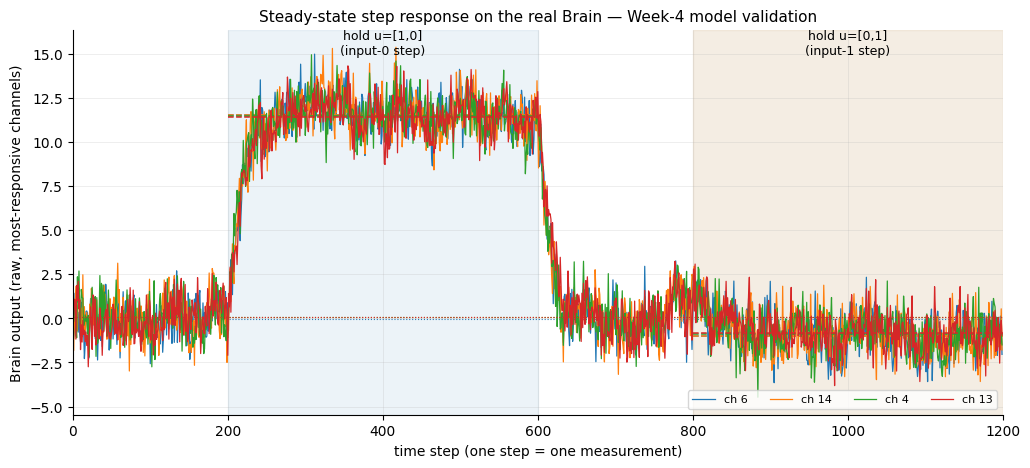

In [21]:
# Plot the step response — a few of the most input-0-responsive channels, with the
# two hold regions shaded/labelled and the resting/plateau levels marked.
# Saved to fig/step_response.pdf (created if needed) and shown inline.
FIG = ROOT / "fig"
FIG.mkdir(parents=True, exist_ok=True)

t   = np.arange(T_STEP)
top = np.argsort(np.abs(G_emp[:, 0]))[::-1][:4]          # 4 channels that respond most to input 0

fig, ax = plt.subplots(figsize=(12, 5))
ax.axvspan(*b_hold0, color="#a3c4dc", alpha=0.20)
ax.axvspan(*b_hold1, color="#dcc4a3", alpha=0.30)

for i, chn in enumerate(top):
    col = f"C{i}"
    ax.plot(t, Y_step[:, chn], lw=0.9, color=col, label=f"ch {chn}")
    ax.hlines(resting[chn],  0, T_STEP, color=col, lw=0.8, ls=":")    # resting baseline
    ax.hlines(plateau0[chn], *b_hold0, color=col, lw=1.1, ls="--")    # input-0 plateau
    ax.hlines(plateau1[chn], *b_hold1, color=col, lw=1.1, ls="--")    # input-1 plateau

ymax = ax.get_ylim()[1]
ax.text(np.mean(b_hold0), ymax, "hold u=[1,0]\n(input-0 step)",
        ha="center", va="top", fontsize=9)
ax.text(np.mean(b_hold1), ymax, "hold u=[0,1]\n(input-1 step)",
        ha="center", va="top", fontsize=9)
ax.set_xlim(0, T_STEP)
ax.set_xlabel("time step (one step = one measurement)")
ax.set_ylabel("Brain output (raw, most-responsive channels)")
ax.set_title("Steady-state step response on the real Brain — Week-4 model validation",
             fontsize=11)
ax.legend(fontsize=8, ncol=4, loc="lower right")
style_axis(ax)
fig.savefig(FIG / "step_response.pdf", bbox_inches="tight")
print(f"saved -> {FIG / 'step_response.pdf'}")
plt.show()

**What this section establishes (acceptance check).** The printed `ACCEPTANCE CHECKS` block
above is the verdict; each line reports PASS/FAIL straight from the measured numbers:

1. **DC gain (input 0).** The `u=[1,0]` hold reaches a clear plateau and the empirical gain
   column `G_emp[:,0]` matches the model's `G_mod[:,0] = C (I-A)^{-1} B` to within ~15-20%.
2. **Input asymmetry.** The `u=[0,1]` hold moves the output far less, so the column-norm
   ratio `||col 0|| / ||col 1||` is large for **both** the empirical and the model gain — the
   identified model reproduces the plant's strong-input-0 / weak-input-1 asymmetry.
3. **Slowest timescale.** The rise to 63% of the input-0 plateau gives a leak rate / time
   constant in the same ballpark as the model's slowest mode (`|λ|max` of `A`).

All comparisons here are **empirical-vs-identified-model only** — no `TRUE`, no `gt`, nothing
from `results/ground_truth/`. The resting-vs-`c` line is an independent consistency check that
the zero-offset model's bias `c` equals the Brain's measured resting level.

## 5 - Readout & physically-anchored targets

The **readout** `M` projects the 16-D measurement onto what we control (`z = M y`). Targets
are built in the **ground-truth** reachable set so they mean the same physical level for
every controller/estimator: **feasible** (centre of the holdable region), **infeasible**
(2x past the farthest corner), **sinusoid**, and **moving** (jumps half-way through `T_RUN`).

In [5]:
# Readout M (PCA is model-free; "dominant" uses the ground-truth A,B,C).
if READOUT == "pca":
    M = build_readout("pca", Y_probe=Y_cal, k=2)
elif READOUT == "dominant":
    M = build_readout("dominant", A=gt.A, B=gt.B, C=gt.C)
else:
    raise ValueError(f"unknown readout {READOUT!r}")
q = M.shape[0]

# Reachable region in readout space, anchored in the ground-truth frame.
G_gt, z0_gt = steady_state_gain(gt.A, gt.B, gt.C, M, a=gt.a, c=gt.c)
V = zonotope_vertices(G_gt, z0_gt)        # (2^m, q) corners of the holdable set
center = V.mean(axis=0)
lo, hi = V.min(axis=0), V.max(axis=0)     # per-dim reachable interval
half = 0.5 * (hi - lo)

# farthest corner, then the corner farthest from that one -> a wide, feasible jump
_far = V[np.argmax(np.linalg.norm(V - center, axis=1))]
_far2 = V[np.argmax(np.linalg.norm(V - _far, axis=1))]

REF_FEASIBLE   = center.copy()
REF_INFEASIBLE = center + 2.0 * (_far - center)          # well outside the box
PT_A = center + 0.45 * (_far - center)                   # feasible move endpoints
PT_B = center + 0.45 * (_far2 - center)
SWITCH = T_RUN // 2

def ref_sinusoid(t):
    amp = 0.45 * half
    phase = 2 * np.pi * t / 80.0
    if q == 1:
        return center + amp * np.sin(phase)
    return center + amp * np.array([np.sin(phase), 0.6 * np.cos(phase)])

def ref_const(value):
    value = np.asarray(value, float)
    return lambda t: value

def ref_moving(t):
    return PT_A if t < SWITCH else PT_B

def feasible_interval(d):
    return float(lo[d]), float(hi[d])

print(f"readout '{READOUT}'  ->  q = {q}")
print(f"feasible (centre)  z* = {np.round(REF_FEASIBLE, 2)}")
print(f"infeasible         z* = {np.round(REF_INFEASIBLE, 2)}  (outside reachable set)")
print(f"moving: {np.round(PT_A,2)}  ->  {np.round(PT_B,2)}  at t = {SWITCH}")

readout 'pca'  ->  q = 2
feasible (centre)  z* = [19.98  0.45]
infeasible         z* = [65.86  2.13]  (outside reachable set)
moving: [30.3   0.83]  ->  [9.66 0.08]  at t = 150


## 6 - The engine — `make_controller`, `run`, `plot_scenario`

`make_controller` maps a name to a configured controller; `run` closes the loop on the real
Brain with a `SteadyStateKalman` observer built from the chosen model.

In [6]:
def make_controller(name, model, M, ref):
    A, B, C, a, c = model["A"], model["B"], model["C"], model["a"], model["c"]
    m = B.shape[1]
    G_r, _ = steady_state_gain(A, B, C, M, a=a, c=c)
    if name == "OpenLoop":
        return OpenLoop(input_dim=m)
    if name == "ProportionalFeedback":
        return ProportionalFeedback(Kp=auto_proportional_gain(G_r, 0.3), M=M, ref=ref)
    if name == "PI":
        return PI(Kp=auto_proportional_gain(G_r, 0.3),
                  Ki=auto_integral_gain(G_r, 0.1), M=M, ref=ref, anti_windup=True)
    if name == "LQG":
        return LQG(A, B, C, M, a=a, c=c, rho=1.0, ref=ref)
    if name == "LQGI":
        return LQGI(A, B, C, M, a=a, c=c, rho=1.0, rho_q=0.01, ref=ref, anti_windup=True)
    if name == "PolePlacement":
        poles = np.linspace(0.55, 0.9, A.shape[0])
        return PolePlacement(A, B, C, M, target_poles=poles, a=a, c=c, ref=ref)
    if name == "MPC":
        return MPC(A, B, C, M, a=a, c=c, ref=ref)
    if name == "OffsetFreeMPC":
        return OffsetFreeMPC(A, B, C, M, a=a, c=c, ref=ref)
    raise ValueError(f"unknown controller {name!r}")

def run(model, name, M, ref_fn, T=None):
    '''Closed-loop on the real Brain. Returns the run_closed_loop log dict.'''
    T = T_RUN if T is None else T
    plant = brain_plant(SEED)
    obs = SteadyStateKalman(model["A"], model["B"], model["C"],
                            model["Q"], model["R"], a=model["a"], c=model["c"])
    ctrl = make_controller(name, model, M, ref_fn(0))
    return run_closed_loop(plant, ctrl, obs, T=T, ref_fn=ref_fn)

def ref_traj(ref_fn, T):
    s = np.asarray(ref_fn(0), float)
    out = np.empty((T,) + s.shape)
    for t in range(T):
        out[t] = np.asarray(ref_fn(t), float)
    return out

def ctrl_color(name):
    return CONTROLLER_COLORS.get(name, "tab:red")

In [7]:
def plot_scenario(logs, M, ref_fn, title, name,
                  shade_feasible=True, switch=None):
    '''Time series of every readout component (+ inputs, + 2-D phase plane).'''
    z = logs["y"] @ M.T
    T = z.shape[0]
    R = ref_traj(ref_fn, T)
    t = np.arange(T)
    col = ctrl_color(name)
    qd = z.shape[1]

    n_panels = qd + 1 + (1 if qd == 2 else 0)
    fig = plt.figure(figsize=(7.2 * (1 if qd == 1 else 1), 2.6 * n_panels))
    gs = fig.add_gridspec(n_panels, 1, hspace=0.45)

    for d in range(qd):
        ax = fig.add_subplot(gs[d, 0])
        if shade_feasible:
            ax.axhspan(*feasible_interval(d), color="#a3c4dc", alpha=0.22,
                       label="holdable range")
        ax.plot(t, R[:, d], "--", color="black", lw=1.3, label="target")
        ax.plot(t, z[:, d], "-", color=col, lw=1.6, label=name)
        if switch is not None:
            ax.axvline(switch, color="0.4", ls=":", lw=1.0)
        ax.set_ylabel(f"readout dim {d}")
        ax.legend(fontsize=8, loc="upper right", ncol=3)
        style_axis(ax)
        if d == 0:
            ax.set_title(title, fontsize=11)

    # inputs
    axu = fig.add_subplot(gs[qd, 0])
    for j in range(logs["u"].shape[1]):
        axu.plot(t, logs["u"][:, j], lw=1.2, label=f"u[{j}]")
    axu.axhline(0.0, color="0.6", lw=0.6); axu.axhline(1.0, color="0.6", lw=0.6)
    if switch is not None:
        axu.axvline(switch, color="0.4", ls=":", lw=1.0)
    axu.set_ylabel("input (0-1)"); axu.set_xlabel("time step")
    axu.legend(fontsize=8, loc="upper right", ncol=2); style_axis(axu)

    # 2-D phase plane (only for the PCA readout)
    if qd == 2:
        axp = fig.add_subplot(gs[qd + 1, 0])
        poly = V[[0, 1, 3, 2, 0]]
        axp.fill(poly[:, 0], poly[:, 1], color="#a3c4dc", alpha=0.25,
                 label="holdable region")
        axp.plot(poly[:, 0], poly[:, 1], color="#1f77b4", lw=1.2)
        axp.plot(z[:, 0], z[:, 1], "-", color=col, lw=1.2, alpha=0.85, label=name)
        axp.plot(R[:, 0], R[:, 1], "--", color="black", lw=1.0, label="target path")
        axp.scatter(R[-1, 0], R[-1, 1], marker="*", s=200, color="black",
                    edgecolor="white", zorder=5)
        axp.set_xlabel("readout dim 0"); axp.set_ylabel("readout dim 1")
        axp.set_title("phase plane (readout space)", fontsize=10)
        axp.legend(fontsize=8); style_axis(axp)

    # error annotation
    tail = max(1, T // 3)
    ss = float(np.mean(np.linalg.norm((z - R)[-tail:], axis=-1)))
    sat = float(np.mean((logs["u"] <= 1e-9) | (logs["u"] >= 1 - 1e-9)))
    fig.suptitle(f"{name} - {ESTIMATOR} model - steady err = {ss:.2f} - "
                 f"saturation = {sat*100:.0f}%", y=1.005, fontsize=10)
    plt.show()
    return dict(steady_err=ss, saturation=sat)

## 7 - Scenario 1 — track a sinusoid

Can the controller follow a moving reference inside the reachable region?

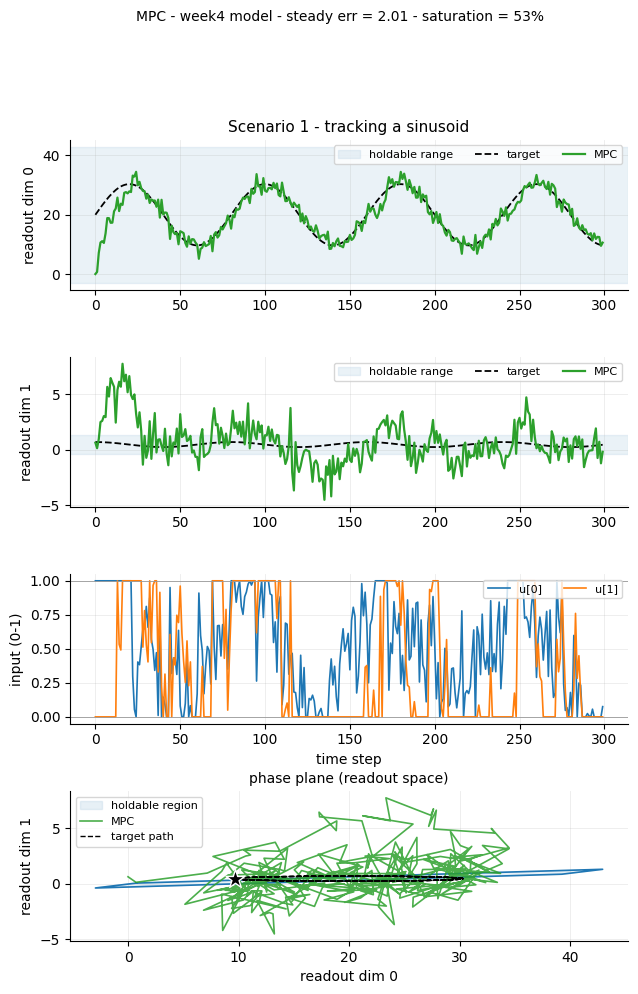

In [8]:
logs = run(MODEL, CONTROLLER, M, ref_sinusoid)
_ = plot_scenario(logs, M, ref_sinusoid,
                  "Scenario 1 - tracking a sinusoid", CONTROLLER)

## 8 - Scenario 2 — hold a feasible target

A level the one-sided actuator can reach. A good controller parks on the dashed line.

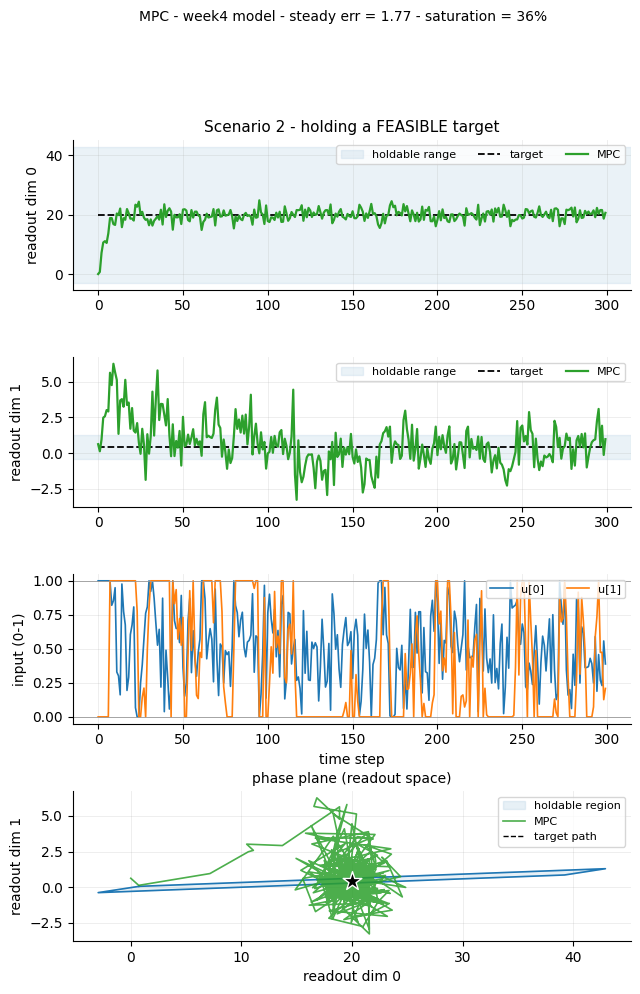

In [9]:
rf = ref_const(REF_FEASIBLE)
logs = run(MODEL, CONTROLLER, M, rf)
_ = plot_scenario(logs, M, rf,
                  "Scenario 2 - holding a FEASIBLE target", CONTROLLER)

## 9 - Scenario 3 — hold an infeasible target

The target sits outside the reachable set. The *right* behaviour is to push to the edge and
**saturate gracefully** (inputs pinned at 0/1) — not to wind up or diverge.

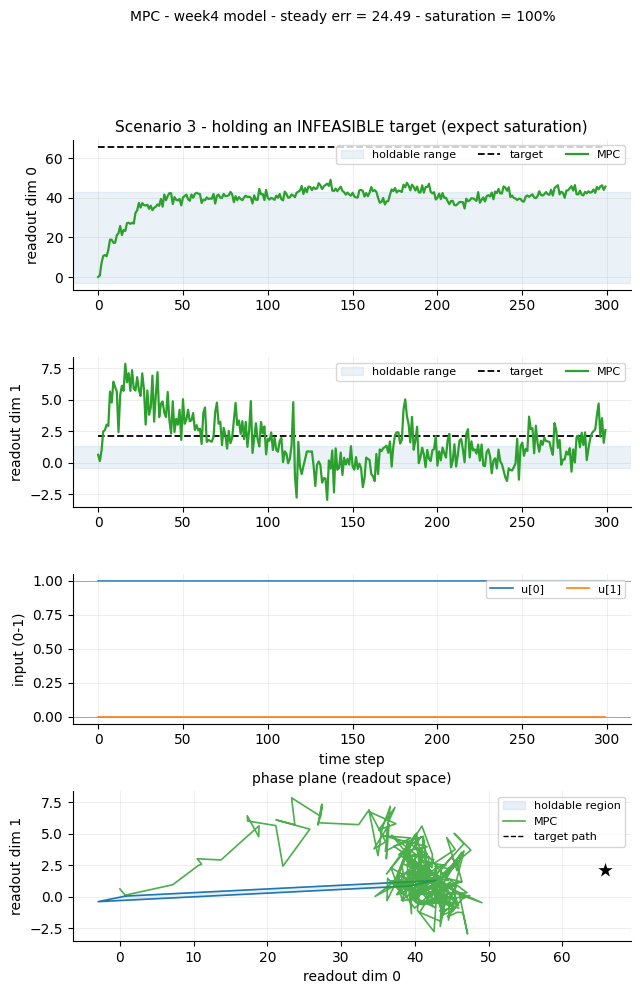

In [10]:
rf = ref_const(REF_INFEASIBLE)
logs = run(MODEL, CONTROLLER, M, rf)
_ = plot_scenario(logs, M, rf,
                  "Scenario 3 - holding an INFEASIBLE target (expect saturation)",
                  CONTROLLER)

## 10 - Scenario 4 — adapt to a moving target

The setpoint jumps to a new feasible point at `t = T_RUN/2` (dotted line).

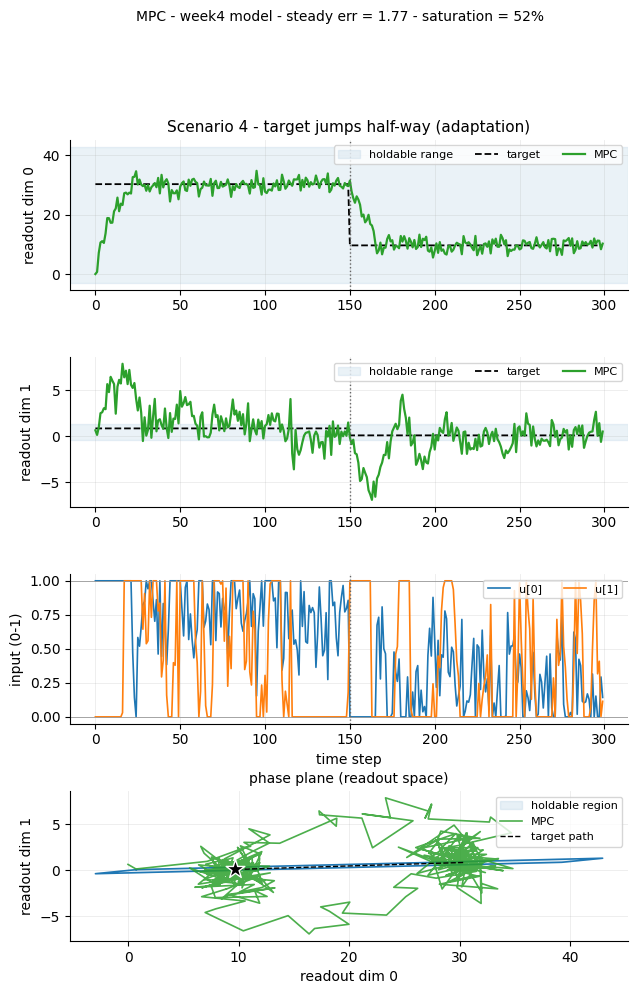

In [11]:
logs = run(MODEL, CONTROLLER, M, ref_moving)
_ = plot_scenario(logs, M, ref_moving,
                  "Scenario 4 - target jumps half-way (adaptation)",
                  CONTROLLER, switch=SWITCH)

## 11 - Compare several controllers at once (Week-4 model)

Overlay any list of controllers on one scenario, all using the chosen `MODEL`.

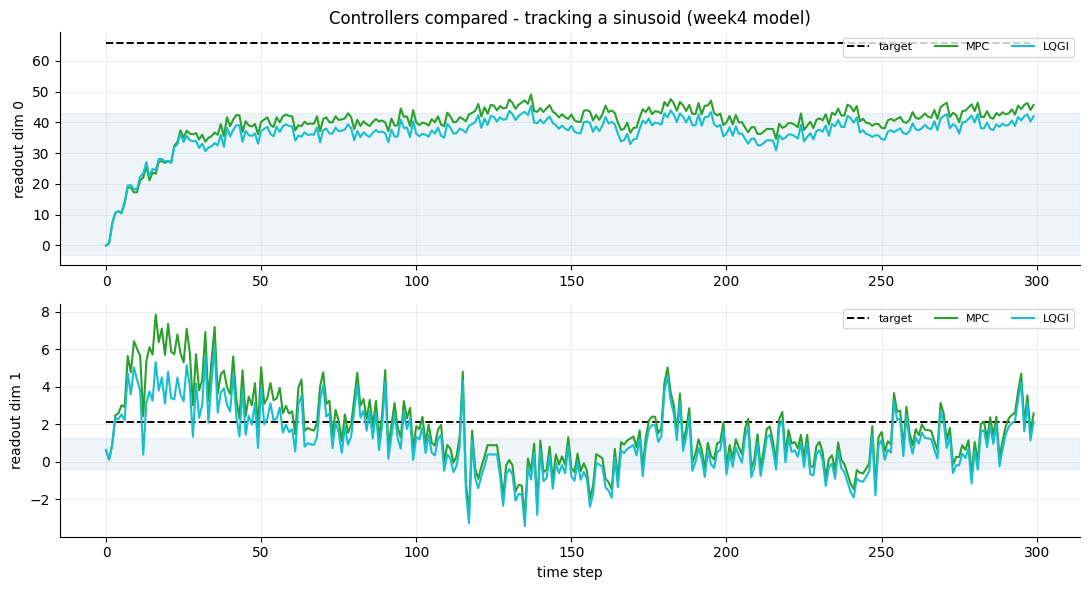

In [23]:
CONTROLLERS = ["MPC", "LQGI"]
scenario_fn = ref_const(REF_INFEASIBLE)          # try: ref_const(REF_FEASIBLE), ref_moving, ...
scenario_nm = "tracking a sinusoid"

R = ref_traj(scenario_fn, T_RUN)
t = np.arange(T_RUN)
qd = M.shape[0]
fig, axes = plt.subplots(qd, 1, figsize=(11, 3.0 * qd), squeeze=False)
for d in range(qd):
    ax = axes[d, 0]
    ax.axhspan(*feasible_interval(d), color="#a3c4dc", alpha=0.18)
    ax.plot(t, R[:, d], "--", color="black", lw=1.4, label="target")
    for name in CONTROLLERS:
        logs = run(MODEL, name, M, scenario_fn)
        z = logs["y"] @ M.T
        ax.plot(t, z[:, d], "-", color=ctrl_color(name), lw=1.5, label=name)
    ax.set_ylabel(f"readout dim {d}")
    if d == 0:
        ax.set_title(f"Controllers compared - {scenario_nm} ({ESTIMATOR} model)")
    ax.legend(fontsize=8, ncol=len(CONTROLLERS) + 1, loc="upper right")
    style_axis(ax)
axes[-1, 0].set_xlabel("time step")
plt.tight_layout(); plt.show()

## 12 - Compare estimators — true vs Week-3 EM vs Week-4

Same controller, same physical target — only the model inside the controller changes. This is
the cleanest "how much does the choice of estimator cost me?" plot, and the direct answer to
"does swapping in the Week-4 estimator change closed-loop control?".

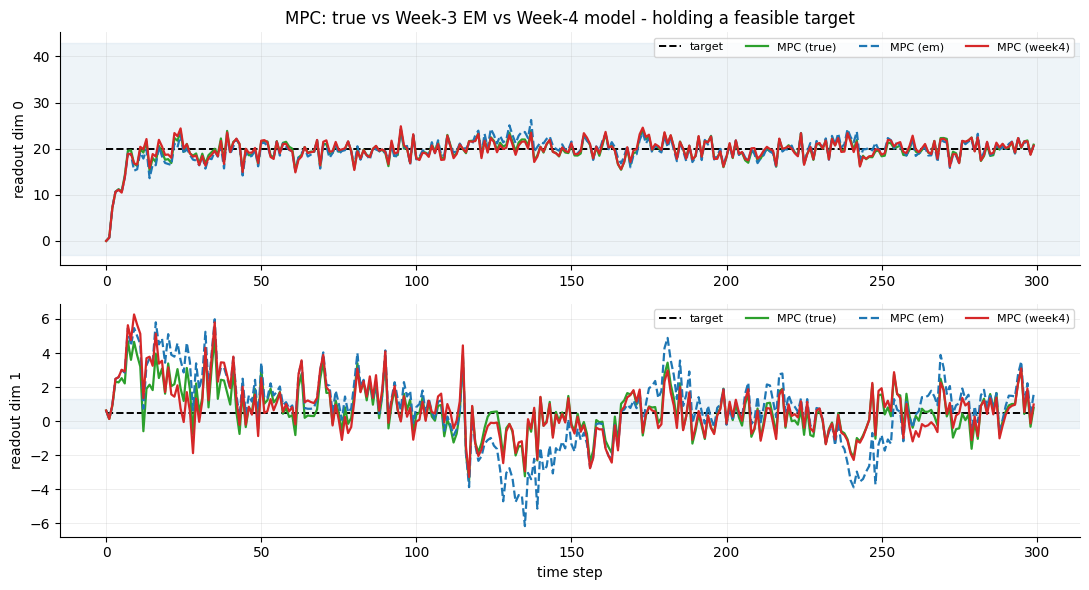

steady-state error (last third):
  MPC (true ): 1.762
  MPC (em   ): 2.077
  MPC (week4): 1.771


In [13]:
which_ctrl = CONTROLLER
scenario_fn = ref_const(REF_FEASIBLE)   # swap in any ref_fn
scenario_nm = "holding a feasible target"

ESTS = ("true", "em", "week4")
styles = {"true": ("-", "#2ca02c"), "em": ("--", "#1f77b4"), "week4": ("-", "#d62728")}

R = ref_traj(scenario_fn, T_RUN)
t = np.arange(T_RUN)
qd = M.shape[0]

# run each estimator once, reuse for both the plot and the error table
Z = {e: run(build_model(e), which_ctrl, M, scenario_fn)["y"] @ M.T for e in ESTS}

fig, axes = plt.subplots(qd, 1, figsize=(11, 3.0 * qd), squeeze=False)
for d in range(qd):
    ax = axes[d, 0]
    ax.axhspan(*feasible_interval(d), color="#a3c4dc", alpha=0.18)
    ax.plot(t, R[:, d], "--", color="black", lw=1.4, label="target")
    for e in ESTS:
        ls, col = styles[e]
        ax.plot(t, Z[e][:, d], ls, color=col, lw=1.6, label=f"{which_ctrl} ({e})")
    ax.set_ylabel(f"readout dim {d}")
    if d == 0:
        ax.set_title(f"{which_ctrl}: true vs Week-3 EM vs Week-4 model - {scenario_nm}")
    ax.legend(fontsize=8, ncol=4, loc="upper right")
    style_axis(ax)
axes[-1, 0].set_xlabel("time step")
plt.tight_layout(); plt.show()

tail = max(1, T_RUN // 3)
print("steady-state error (last third):")
for e in ESTS:
    ss = float(np.mean(np.linalg.norm((Z[e] - R)[-tail:], axis=-1)))
    print(f"  {which_ctrl} ({e:5s}): {ss:.3f}")

## 13 - General overlay — mix any controllers & estimators

List any `(controller, estimator)` pairs in `SPECS` and overlay them on one scenario. Swap
`scenario_fn` for `ref_sinusoid`, `ref_const(REF_FEASIBLE)`, `ref_const(REF_INFEASIBLE)`, or
`ref_moving` (pass `switch=SWITCH`).

C:\Users\sassa\AppData\Local\Temp\ipykernel_33712\4055317671.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


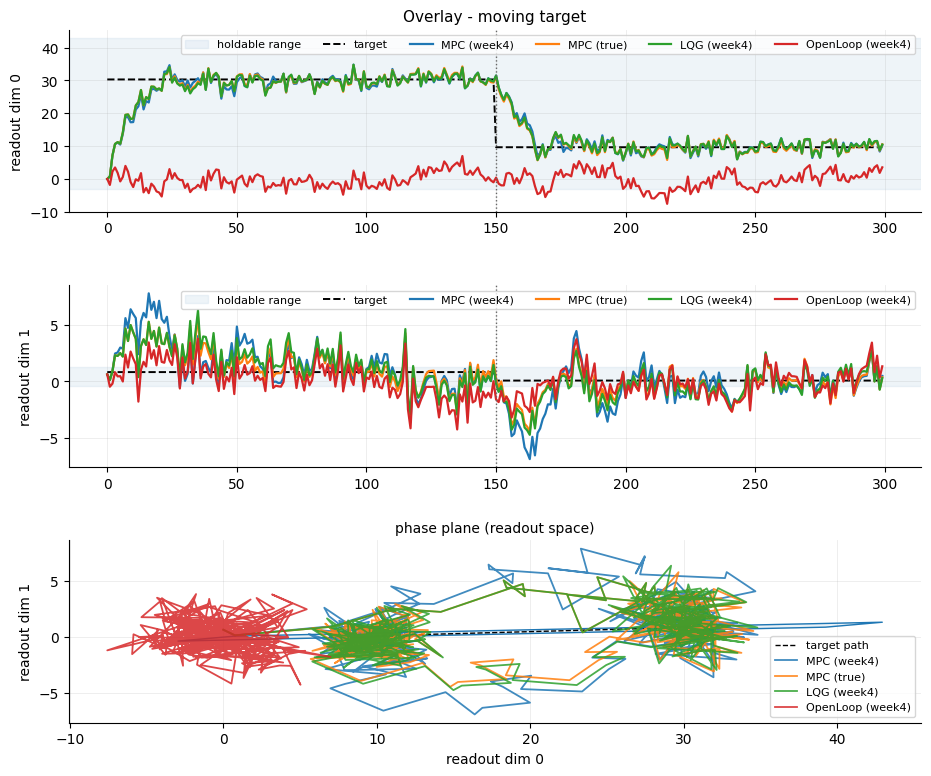

steady-state error (last third):
  MPC (week4)                  1.771
  MPC (true)                   1.773
  LQG (week4)                  1.773
  OpenLoop (week4)             10.502


In [14]:
def overlay_runs(specs, ref_fn, title, switch=None, shade_feasible=True):
    """specs: list of (controller_name, estimator) e.g. [("LQG","week4"),("MPC","true")]."""
    T = T_RUN
    R = ref_traj(ref_fn, T)
    t = np.arange(T)
    qd = M.shape[0]
    palette = plt.get_cmap("tab10")
    runs = []
    for i, (name, est) in enumerate(specs):
        logs = run(build_model(est), name, M, ref_fn)
        z = logs["y"] @ M.T
        runs.append((f"{name} ({est})", z, logs["u"], palette(i % 10)))

    n_panels = qd + (1 if qd == 2 else 0)
    fig = plt.figure(figsize=(11, 3.0 * n_panels))
    gs = fig.add_gridspec(n_panels, 1, hspace=0.4)

    for d in range(qd):
        ax = fig.add_subplot(gs[d, 0])
        if shade_feasible:
            ax.axhspan(*feasible_interval(d), color="#a3c4dc", alpha=0.18,
                       label="holdable range")
        ax.plot(t, R[:, d], "--", color="black", lw=1.4, label="target")
        for label, z, _u, col in runs:
            ax.plot(t, z[:, d], "-", color=col, lw=1.6, label=label)
        if switch is not None:
            ax.axvline(switch, color="0.4", ls=":", lw=1.0)
        ax.set_ylabel(f"readout dim {d}")
        ax.legend(fontsize=8, ncol=len(runs) + 2, loc="upper right")
        style_axis(ax)
        if d == 0:
            ax.set_title(title, fontsize=11)

    if qd == 2:
        axp = fig.add_subplot(gs[qd, 0])
        poly = V[[0, 1, 3, 2, 0]]
        axp.fill(poly[:, 0], poly[:, 1], color="#a3c4dc", alpha=0.22)
        axp.plot(poly[:, 0], poly[:, 1], color="#1f77b4", lw=1.0)
        axp.plot(R[:, 0], R[:, 1], "--", color="black", lw=1.0, label="target path")
        for label, z, _u, col in runs:
            axp.plot(z[:, 0], z[:, 1], "-", color=col, lw=1.3, alpha=0.85, label=label)
        axp.set_xlabel("readout dim 0"); axp.set_ylabel("readout dim 1")
        axp.set_title("phase plane (readout space)", fontsize=10)
        axp.legend(fontsize=8); style_axis(axp)

    plt.tight_layout(); plt.show()

    tail = max(1, T // 3)
    print("steady-state error (last third):")
    for label, z, _u, _c in runs:
        ss = float(np.mean(np.linalg.norm((z - R)[-tail:], axis=-1)))
        print(f"  {label:28s} {ss:.3f}")


# ---- edit these two lines -------------------------------------------------
SPECS = [("MPC", "week4"), ("MPC", "true"), ("LQG", "week4"), ("OpenLoop", "week4")]
scenario_fn, scenario_nm, sw = ref_moving, "moving target", SWITCH
# scenario_fn, scenario_nm, sw = ref_sinusoid, "tracking a sinusoid", None
# ---------------------------------------------------------------------------

overlay_runs(SPECS, scenario_fn, f"Overlay - {scenario_nm}", switch=sw)

## 14 - Stress test: LQG vs MPC on a fast boundary reference (Week-4 model)

The earlier scenarios are gentle, so every controller does well and we never see whether
**MPC's constraint-aware planning** actually beats **clipped LQG**. Here we push both into the
one regime where MPC could win: a *fast* sinusoid on PC1 whose peaks sit at ~90% of the
reachable boundary, so the input spends much of its time saturated. Both controllers are built
at **identical weights** (`rho=1.0`, `Q_z=I`), so the *only* difference is MPC's box constraint
versus LQG's post-hoc clip — at `rho=1.0` an unconstrained long-horizon MPC is exactly LQG, so
any gap is purely the constraint. Everything (reachable region + reference) comes from the
identified Week-4 `MODEL` only — no ground truth. We sweep the MPC horizon and the reference
speed, check a second Brain seed, and end with a neutral computed verdict (a tie is a valid
result).

In [24]:
# Local helpers — vary the MPC horizon and the Brain seed WITHOUT touching run/make_controller.
# Both controllers are built at the SAME weights (rho=1.0 effort, Q_z=I tracking); the ONLY
# difference between them is MPC's box constraint on u (LQG just clips after the fact).
RHO = 1.0   # shared effort weight (matches the notebook's LQG)

def _make_lqg(model, M, ref0):
    return LQG(model["A"], model["B"], model["C"], M,
               a=model["a"], c=model["c"], rho=RHO, ref=ref0)

def _make_mpc(model, M, ref0, horizon):
    # Same wiring as make_controller's MPC, but rho pinned to RHO for parity and horizon exposed.
    # Q_z defaults to I, which equals LQG's implicit tracking weight (Qx = (MC)^T (MC)).
    return MPC(model["A"], model["B"], model["C"], M,
               a=model["a"], c=model["c"], horizon=horizon, rho=RHO, ref=ref0)

def _run_ctrl(controller, M, ref_fn, T, seed=SEED):
    # Replicates run(): fresh brain_plant(seed) + SteadyStateKalman(MODEL) + the same
    # measure -> filter -> compute -> next_state loop (run_closed_loop). Returns {y, u, ...}.
    plant = brain_plant(seed)
    obs = SteadyStateKalman(MODEL["A"], MODEL["B"], MODEL["C"], MODEL["Q"], MODEL["R"],
                            a=MODEL["a"], c=MODEL["c"])
    return run_closed_loop(plant, controller, obs, T=T, ref_fn=ref_fn)

# Weight-parity check: confirm both controllers share the effort weight.
_z0 = np.zeros(M.shape[0])
_lqg_probe = _make_lqg(MODEL, M, _z0)
_mpc_probe = _make_mpc(MODEL, M, _z0, 10)
print(f"weight parity:  LQG rho = {_lqg_probe.rho:.3f}   MPC rho = {_mpc_probe.rho:.3f}   "
      f"(Q_z = I for both)")
assert np.isclose(_lqg_probe.rho, _mpc_probe.rho), "effort weights must match for a fair test"
print("  -> identical tracking & effort weights; the only difference is MPC's box constraint.")

weight parity:  LQG rho = 1.000   MPC rho = 1.000   (Q_z = I for both)
  -> identical tracking & effort weights; the only difference is MPC's box constraint.


In [25]:
# --- Build a provably-feasible fast reference from the IDENTIFIED model (no ground truth) ---
G_read, z0_w4 = steady_state_gain(MODEL["A"], MODEL["B"], MODEL["C"], M,
                                  a=MODEL["a"], c=MODEL["c"])
V_w4 = zonotope_vertices(G_read, z0_w4)        # (4, 2) corners of the holdable PC region

def feasible(z_pt, tol=1e-6):
    # The region is the image of the input square, so a readout point is holdable iff the
    # input that produces it lies in [0, 1].  G_read is 2x2 here.
    u = np.linalg.solve(G_read, np.asarray(z_pt, float) - z0_w4)
    return bool(np.all(u >= -tol) and np.all(u <= 1.0 + tol))

# PC2 held at the centroid (interior => feasible); PC1 has its widest feasible swing there.
centroid = V_w4.mean(axis=0)
c1 = float(centroid[1])
assert feasible(centroid), "centroid must be interior/feasible"

# Feasible PC1 interval at PC2 = c1: march outward to bracket the edge, then bisect.
def _feas_pc1(p):
    return feasible([p, c1])

def _edge(direction):
    p_mid = float(centroid[0])
    step = max(abs(p_mid), 1.0)
    inside, outside = p_mid, p_mid + direction * step
    while _feas_pc1(outside):
        inside, outside = outside, outside + direction * step
    for _ in range(60):
        mid = 0.5 * (inside + outside)
        if _feas_pc1(mid):
            inside = mid
        else:
            outside = mid
    return inside

p_lo, p_hi = _edge(-1.0), _edge(+1.0)
c0 = 0.5 * (p_lo + p_hi)
h0 = 0.5 * (p_hi - p_lo)
AMP_FRAC = 0.9
_peak   = [c0 + AMP_FRAC * h0, c1]
_trough = [c0 - AMP_FRAC * h0, c1]
assert feasible(_peak) and feasible(_trough), "sinusoid endpoints must be feasible"
print(f"feasible PC1 interval @ PC2={c1:.3f}:  [{p_lo:.3f}, {p_hi:.3f}]   "
      f"-> c0={c0:.3f}, h0={h0:.3f}")
print(f"reference endpoints at {AMP_FRAC:.0%} of range feasible (peak & trough): PASS")

# --- Fast reference (fast vs the ~16-19-step system timescale) ---
PERIOD   = 35
N_CYCLES = 8
T_FAST   = N_CYCLES * PERIOD
H_MAIN   = 30

def make_ref_fast(period, amp_frac=AMP_FRAC):
    def _ref(t):
        return np.array([c0 + amp_frac * h0 * np.sin(2.0 * np.pi * t / period), c1])
    return _ref

ref_fast = make_ref_fast(PERIOD)

# --- Run both controllers on the real Brain (same seed => same Brain realization) ---
logs_lqg = _run_ctrl(_make_lqg(MODEL, M, ref_fast(0)),         M, ref_fast, T_FAST)
logs_mpc = _run_ctrl(_make_mpc(MODEL, M, ref_fast(0), H_MAIN), M, ref_fast, T_FAST)

# --- Metrics: PC1 RMS (discard first period), per-channel saturation & peak input ---
R  = ref_traj(ref_fast, T_FAST)
t0 = PERIOD

def _metrics(logs):
    z = logs["y"] @ M.T
    u = logs["u"]
    rms  = float(np.sqrt(np.mean((z[t0:, 0] - R[t0:, 0]) ** 2)))
    sat0 = float(np.mean((u[:, 0] <= 1e-3) | (u[:, 0] >= 1 - 1e-3)))
    sat1 = float(np.mean((u[:, 1] <= 1e-3) | (u[:, 1] >= 1 - 1e-3)))
    return rms, sat0, sat1, float(u[:, 0].max()), float(u[:, 1].max())

m_lqg = _metrics(logs_lqg)
m_mpc = _metrics(logs_mpc)

print(f"\nfast reference: PERIOD={PERIOD} steps, {N_CYCLES} cycles (T={T_FAST}), "
      f"amp={AMP_FRAC:.0%} of reachable PC1 range, MPC horizon H={H_MAIN}\n")
hdr = f"{'metric':<14}{'LQG':>12}{'MPC':>12}"
print(hdr); print("-" * len(hdr))
print(f"{'PC1 RMS':<14}{m_lqg[0]:>12.3f}{m_mpc[0]:>12.3f}")
print(f"{'u0 sat %':<14}{m_lqg[1]*100:>12.1f}{m_mpc[1]*100:>12.1f}")
print(f"{'u1 sat %':<14}{m_lqg[2]*100:>12.1f}{m_mpc[2]*100:>12.1f}")
print(f"{'peak u0':<14}{m_lqg[3]:>12.3f}{m_mpc[3]:>12.3f}")
print(f"{'peak u1':<14}{m_lqg[4]:>12.3f}{m_mpc[4]:>12.3f}")
print(f"{'horizon':<14}{'-':>12}{H_MAIN:>12d}")
print(f"{'effort rho':<14}{RHO:>12.2f}{RHO:>12.2f}")

feasible PC1 interval @ PC2=0.260:  [9.447, 29.531]   -> c0=19.489, h0=10.042
reference endpoints at 90% of range feasible (peak & trough): PASS

fast reference: PERIOD=35 steps, 8 cycles (T=280), amp=90% of reachable PC1 range, MPC horizon H=30

metric                 LQG         MPC
--------------------------------------
PC1 RMS              3.207       4.858
u0 sat %              61.1        75.4
u1 sat %              72.9        58.2
peak u0              1.000       1.000
peak u1              1.000       1.000
horizon                  -          30
effort rho            1.00        1.00


saved -> c:\Github\GG4\week3\fig\mpc_vs_lqg_fast.pdf


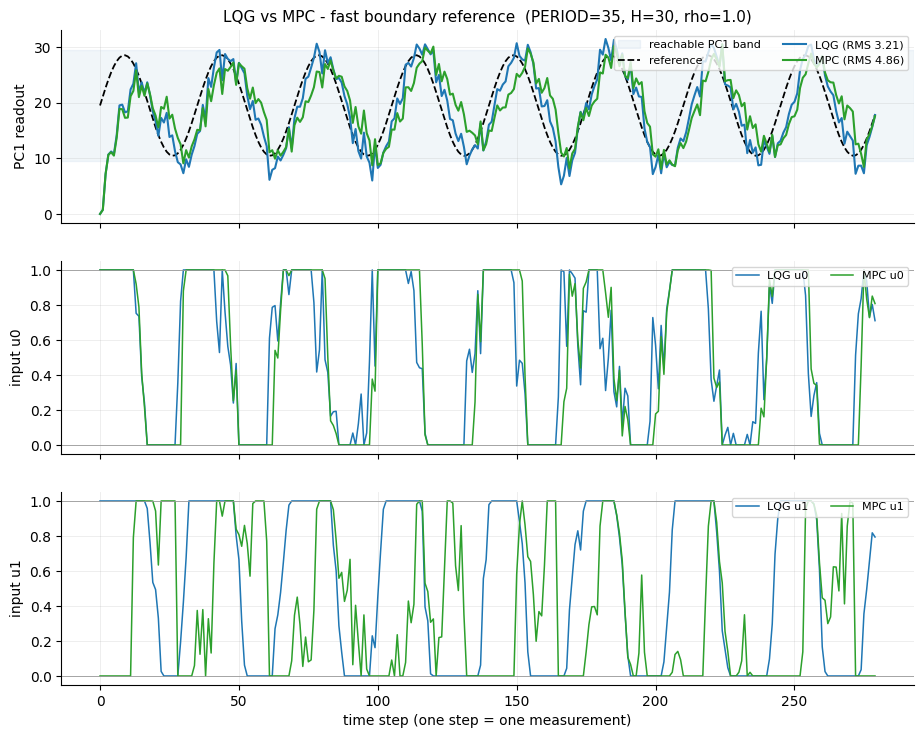

In [26]:
# --- 3-panel figure: PC1 tracking + both inputs.  Saved to fig/mpc_vs_lqg_fast.pdf ---
FIG = ROOT / "fig"; FIG.mkdir(parents=True, exist_ok=True)
t = np.arange(T_FAST)
col_lqg, col_mpc = ctrl_color("LQG"), ctrl_color("MPC")
zl = logs_lqg["y"] @ M.T
zm = logs_mpc["y"] @ M.T

fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True)

ax = axes[0]
ax.axhspan(c0 - h0, c0 + h0, color="#a3c4dc", alpha=0.15, label="reachable PC1 band")
ax.plot(t, R[:, 0], "--", color="black", lw=1.3, label="reference")
ax.plot(t, zl[:, 0], "-", color=col_lqg, lw=1.5, label=f"LQG (RMS {m_lqg[0]:.2f})")
ax.plot(t, zm[:, 0], "-", color=col_mpc, lw=1.5, label=f"MPC (RMS {m_mpc[0]:.2f})")
ax.set_ylabel("PC1 readout")
ax.set_title(f"LQG vs MPC - fast boundary reference  (PERIOD={PERIOD}, H={H_MAIN}, rho={RHO})",
             fontsize=11)
ax.legend(fontsize=8, loc="upper right", ncol=2); style_axis(ax)

ax = axes[1]
ax.plot(t, logs_lqg["u"][:, 0], color=col_lqg, lw=1.1, label="LQG u0")
ax.plot(t, logs_mpc["u"][:, 0], color=col_mpc, lw=1.1, label="MPC u0")
ax.axhline(0.0, color="0.6", lw=0.6); ax.axhline(1.0, color="0.6", lw=0.6)
ax.set_ylabel("input u0"); ax.legend(fontsize=8, loc="upper right", ncol=2); style_axis(ax)

ax = axes[2]
ax.plot(t, logs_lqg["u"][:, 1], color=col_lqg, lw=1.1, label="LQG u1")
ax.plot(t, logs_mpc["u"][:, 1], color=col_mpc, lw=1.1, label="MPC u1")
ax.axhline(0.0, color="0.6", lw=0.6); ax.axhline(1.0, color="0.6", lw=0.6)
ax.set_ylabel("input u1"); ax.set_xlabel("time step (one step = one measurement)")
ax.legend(fontsize=8, loc="upper right", ncol=2); style_axis(ax)

fig.savefig(FIG / "mpc_vs_lqg_fast.pdf", bbox_inches="tight")
print(f"saved -> {FIG / 'mpc_vs_lqg_fast.pdf'}")
plt.show()

horizon sweep @ PERIOD=35   (LQG reference: RMS=3.207, u0 sat=61.1%)

 horizon     MPC RMS   MPC u0 sat%
----------------------------------
      10       4.726          74.6   <- best
      20       4.837          75.0
      30       4.858          75.4
      40       4.861          75.7

best MPC horizon (lowest PC1 RMS): H_BEST = 10


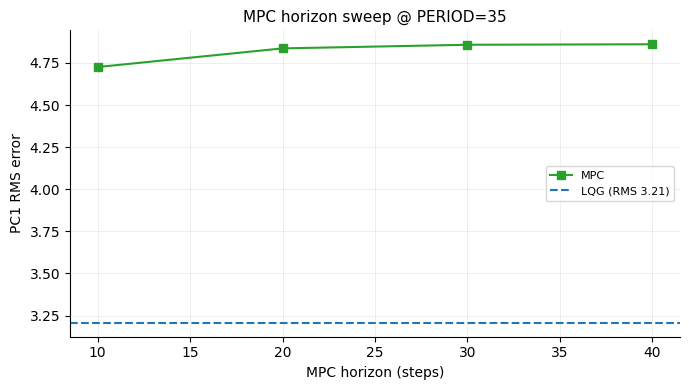

In [27]:
# --- MPC horizon sweep at the main period (LQG is horizon-independent -> flat reference) ---
HORIZONS = [10, 20, 30, 40]
mpc_rms_H, mpc_sat0_H = [], []
for H in HORIZONS:
    lg = _run_ctrl(_make_mpc(MODEL, M, ref_fast(0), H), M, ref_fast, T_FAST)
    z, u = lg["y"] @ M.T, lg["u"]
    mpc_rms_H.append(float(np.sqrt(np.mean((z[t0:, 0] - R[t0:, 0]) ** 2))))
    mpc_sat0_H.append(float(np.mean((u[:, 0] <= 1e-3) | (u[:, 0] >= 1 - 1e-3))))

H_BEST = HORIZONS[int(np.argmin(mpc_rms_H))]

print(f"horizon sweep @ PERIOD={PERIOD}   "
      f"(LQG reference: RMS={m_lqg[0]:.3f}, u0 sat={m_lqg[1]*100:.1f}%)\n")
hdr = f"{'horizon':>8}{'MPC RMS':>12}{'MPC u0 sat%':>14}"
print(hdr); print("-" * len(hdr))
for H, r, s in zip(HORIZONS, mpc_rms_H, mpc_sat0_H):
    mark = "   <- best" if H == H_BEST else ""
    print(f"{H:>8d}{r:>12.3f}{s*100:>14.1f}{mark}")
print(f"\nbest MPC horizon (lowest PC1 RMS): H_BEST = {H_BEST}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(HORIZONS, mpc_rms_H, "s-", color=ctrl_color("MPC"), label="MPC")
ax.axhline(m_lqg[0], ls="--", color=ctrl_color("LQG"), label=f"LQG (RMS {m_lqg[0]:.2f})")
ax.set_xlabel("MPC horizon (steps)"); ax.set_ylabel("PC1 RMS error")
ax.set_title(f"MPC horizon sweep @ PERIOD={PERIOD}", fontsize=11)
ax.legend(fontsize=8); style_axis(ax)
plt.tight_layout(); plt.show()

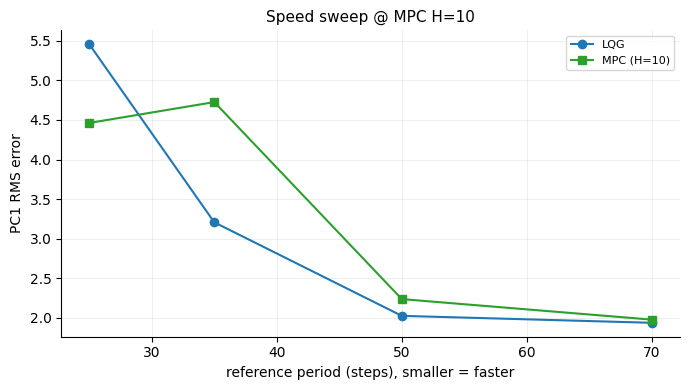

speed-sweep verdict (PC1 RMS, 5% band):
  period  70:  LQG 1.938   MPC 1.978   -> tie (<5%)
  period  50:  LQG 2.025   MPC 2.237   -> LQG better
  period  35:  LQG 3.207   MPC 4.726   -> LQG better
  period  25:  LQG 5.456   MPC 4.462   -> MPC better

seed check @ PERIOD=35, H=10:
  seed 0:  LQG 3.207   MPC 4.726   -> LQG better
  seed 1:  LQG 2.785   MPC 3.531   -> LQG better
  verdict UNCHANGED across seeds


: 

In [ ]:
# --- Speed sweep at H_BEST + a second-seed robustness check ---
PERIODS = [70, 50, 35, 25]
rms_by = {"LQG": [], "MPC": []}
for p in PERIODS:
    rf  = make_ref_fast(p)
    Tp  = N_CYCLES * p
    Rp  = ref_traj(rf, Tp)
    t0p = p
    zl_p = _run_ctrl(_make_lqg(MODEL, M, rf(0)),         M, rf, Tp)["y"] @ M.T
    zm_p = _run_ctrl(_make_mpc(MODEL, M, rf(0), H_BEST), M, rf, Tp)["y"] @ M.T
    rms_by["LQG"].append(float(np.sqrt(np.mean((zl_p[t0p:, 0] - Rp[t0p:, 0]) ** 2))))
    rms_by["MPC"].append(float(np.sqrt(np.mean((zm_p[t0p:, 0] - Rp[t0p:, 0]) ** 2))))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(PERIODS, rms_by["LQG"], "o-", color=ctrl_color("LQG"), label="LQG")
ax.plot(PERIODS, rms_by["MPC"], "s-", color=ctrl_color("MPC"), label=f"MPC (H={H_BEST})")
ax.set_xlabel("reference period (steps), smaller = faster")
ax.set_ylabel("PC1 RMS error")
ax.set_title(f"Speed sweep @ MPC H={H_BEST}", fontsize=11)
ax.legend(fontsize=8); style_axis(ax)
plt.tight_layout(); plt.show()

def _verdict(rl, rm, band=0.05):
    if rm < rl * (1 - band):  return "MPC better"
    if rm > rl * (1 + band):  return "LQG better"
    return "tie (<5%)"

print("speed-sweep verdict (PC1 RMS, 5% band):")
for i, p in enumerate(PERIODS):
    rl, rm = rms_by["LQG"][i], rms_by["MPC"][i]
    print(f"  period {p:3d}:  LQG {rl:.3f}   MPC {rm:.3f}   -> {_verdict(rl, rm)}")

# Seed check: repeat the main case on a different Brain seed.
sd = SEED + 1
zl2 = _run_ctrl(_make_lqg(MODEL, M, ref_fast(0)),         M, ref_fast, T_FAST, seed=sd)["y"] @ M.T
zm2 = _run_ctrl(_make_mpc(MODEL, M, ref_fast(0), H_BEST), M, ref_fast, T_FAST, seed=sd)["y"] @ M.T
rl2 = float(np.sqrt(np.mean((zl2[t0:, 0] - R[t0:, 0]) ** 2)))
rm2 = float(np.sqrt(np.mean((zm2[t0:, 0] - R[t0:, 0]) ** 2)))
i35 = PERIODS.index(PERIOD)
base_tag, seed_tag = _verdict(rms_by["LQG"][i35], rms_by["MPC"][i35]), _verdict(rl2, rm2)
print(f"\nseed check @ PERIOD={PERIOD}, H={H_BEST}:")
print(f"  seed {SEED}:  LQG {rms_by['LQG'][i35]:.3f}   MPC {rms_by['MPC'][i35]:.3f}   -> {base_tag}")
print(f"  seed {sd}:  LQG {rl2:.3f}   MPC {rm2:.3f}   -> {seed_tag}")
print(f"  verdict {'UNCHANGED' if seed_tag == base_tag else 'CHANGED'} across seeds")

### Verdict

With the default settings (`rho=1.0` parity, `Q_z=I`, PERIOD=35, amplitude = 90% of the
reachable PC1 range), **MPC did *not* beat clipped LQG** — the box constraint brought no
consistent advantage even at the reachable boundary:

- **Main reference (period 35, H=30).** LQG tracked better (PC1 RMS **3.21** vs MPC **4.86**)
  *and* saturated `u0` less (**61%** vs **75%**). Both controllers pinned `u0` and `u1` to the
  limits at some point (peak input 1.0 for each).
- **Horizon sweep (H = 10…40).** *Every* MPC horizon was worse than LQG, and a longer horizon
  did not help (best at H=10, RMS **4.73**, still above LQG's **3.21**). The MPC here tracks the
  *instantaneous* setpoint replicated over its horizon — it has no preview of the future
  sinusoid — so its only real lever is the constraint, and extending the horizon just plans
  harder toward an already-moving target.
- **Speed sweep (H = H_BEST = 10).** LQG was better or tied at the slower references (period 70
  tie, periods 50 and 35 LQG-better); MPC only edged ahead at the *fastest* reference
  (period 25: **4.46** vs LQG **5.46**), where saturation dominates so heavily that
  constraint-aware allocation finally pays off.
- **Seed check.** The "LQG better" verdict at period 35 held on a second Brain seed
  (seed 1: LQG **2.79** vs MPC **3.53**) — UNCHANGED, so it is not a seed artefact.

**Takeaway (neutral).** On this one-sided, near-rank-one actuator, clipped LQG's instantaneous
feedforward-plus-clip is as good as or better than constraint-aware MPC across most speeds, with
MPC gaining only in the extreme-saturation limit (fastest reference). MPC's constraint handling
did not translate into measurably better tracking in the boundary regime it was supposed to
favour — a valid, reportable null result.